# IMPORT

In [130]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import joblib
from pathlib import Path

# setting visual
plt.style.use('default')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

# LOAD CSV

In [131]:
from pathlib import Path

# path CSV relatif dari notebook preproc.ipynb
RAW_PATH = '../dataset/IMS_Data_200725-200726.csv'

# output
PROCESSED_DIR = Path('../dataset/PatchTST processed')
ARTIFACT_DIR = Path('../PatchTST/artifacts')

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

print('Current working directory:')
print(Path.cwd())

print('\nCSV path:')
print(Path(RAW_PATH).resolve())

Current working directory:
d:\Kuliah\GAWE\PERTAMINA\IMS-Model-Analytic\PatchTST

CSV path:
D:\Kuliah\GAWE\PERTAMINA\IMS-Model-Analytic\dataset\IMS_Data_200725-200726.csv


In [132]:
df = pd.read_csv(RAW_PATH)

print('Shape awal:', df.shape)
df.head()

Shape awal: (1200, 8)


,Source,TagName,DateTime,State,Value,Unit,Quality,QualityStatus
0,NaN,PTG_A3_CTK_PT_002.ValueQuery,7/20/2025 12:00:00.000 am,NaN,288.275,NaN,192,Good
1,NaN,PTG_A3_CTK_PT_002.ValueQuery,7/20/2025 12:04:08.431 am,NaN,287.925,NaN,192,Good
2,NaN,PTG_A3_CTK_PT_002.ValueQuery,7/21/2025 3:55:25.663 am,NaN,345.527,NaN,192,Good
3,NaN,PTG_A3_CTK_PT_002.ValueQuery,7/21/2025 3:59:25.666 am,NaN,345.241,NaN,192,Good
4,NaN,PTG_A3_CTK_PT_002.ValueQuery,7/21/2025 4:00:25.733 am,NaN,345.244,NaN,192,Good


In [133]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Source         0 non-null      float64
 1   TagName        1200 non-null   object 
 2   DateTime       1200 non-null   object 
 3   State          0 non-null      float64
 4   Value          1200 non-null   float64
 5   Unit           0 non-null      float64
 6   Quality        1200 non-null   int64  
 7   QualityStatus  1200 non-null   object 
dtypes: float64(4), int64(1), object(3)
memory usage: 75.1+ KB
None


# PROCESSING

In [134]:
df = df[df['QualityStatus'] == 'Good'].copy()

print('Jumlah data setelah filter QualityStatus=Good:', len(df))

Jumlah data setelah filter QualityStatus=Good: 1177


In [135]:
df = df[['DateTime', 'Value']].copy()
df.columns = ['timestamp', 'pressure']

df.head()

,timestamp,pressure
0,7/20/2025 12:00:00.000 am,288.275
1,7/20/2025 12:04:08.431 am,287.925
2,7/21/2025 3:55:25.663 am,345.527
3,7/21/2025 3:59:25.666 am,345.241
4,7/21/2025 4:00:25.733 am,345.244


In [136]:
# timestamp
df['timestamp'] = pd.to_datetime(df['timestamp'])

# pressure
df['pressure'] = pd.to_numeric(df['pressure'], errors='coerce')

# hapus NaN
df = df.dropna()

print(df.dtypes)
print('Jumlah data:', len(df))

timestamp    datetime64[ns]
pressure            float64
dtype: object
Jumlah data: 1177


C:\Users\Zepunnn\AppData\Local\Temp\ipykernel_6256\1486015117.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['timestamp'] = pd.to_datetime(df['timestamp'])


In [137]:
df = df.sort_values('timestamp').reset_index(drop=True)

print('Data paling awal :', df['timestamp'].min())
print('Data paling akhir:', df['timestamp'].max())

df.head()

Data paling awal : 2025-07-20 00:00:00
Data paling akhir: 2026-07-20 08:34:16


,timestamp,pressure
0,2025-07-20 00:00:00.000,288.275
1,2025-07-20 00:04:08.431,287.925
2,2025-07-21 03:55:25.663,345.527
3,2025-07-21 03:59:25.666,345.241
4,2025-07-21 04:00:25.733,345.244


# PERIOD FILTER

In [138]:
invalid_start = pd.Timestamp('2025-08-01 00:00:00')
invalid_end   = pd.Timestamp('2026-04-30 23:59:59')

print('Periode tidak valid:')
print(invalid_start, 'sampai', invalid_end)

Periode tidak valid:
2025-08-01 00:00:00 sampai 2026-04-30 23:59:59


In [139]:
# Segmen A: sebelum 1 Aug 2025
segment_a = df[df['timestamp'] < invalid_start].copy()

# Segmen B: setelah 30 Apr 2026
segment_b = df[df['timestamp'] > invalid_end].copy()

print('Segmen A:', len(segment_a))
print('Segmen B:', len(segment_b))
print('Total valid:', len(segment_a) + len(segment_b))

Segmen A: 42
Segmen B: 266
Total valid: 308


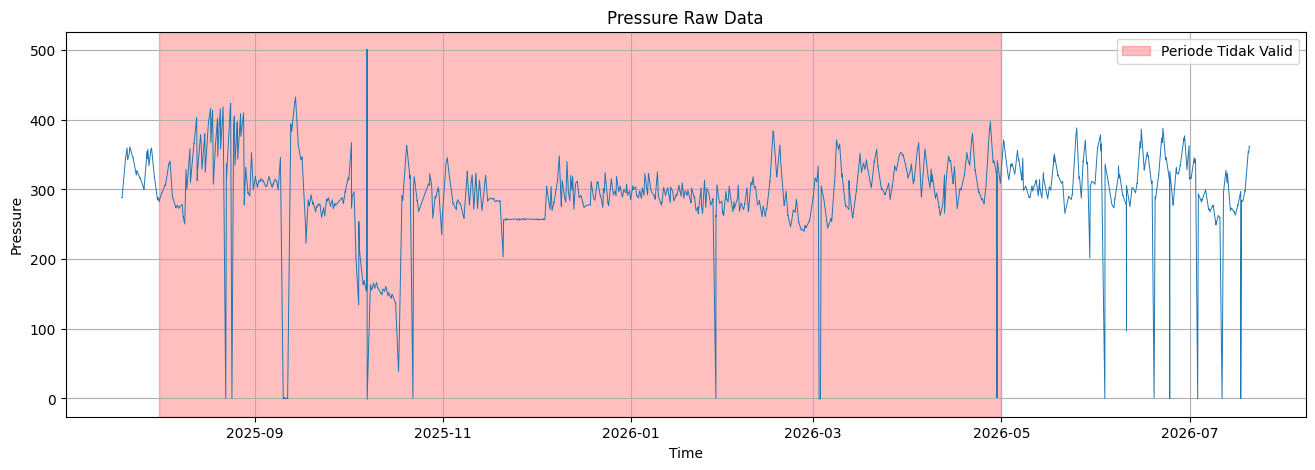

In [140]:
plt.figure(figsize=(16,5))

plt.plot(df['timestamp'], df['pressure'], linewidth=0.7)

plt.axvspan(
    invalid_start,
    invalid_end,
    color='red',
    alpha=0.25,
    label='Periode Tidak Valid'
)

plt.title('Pressure Raw Data')
plt.xlabel('Time')
plt.ylabel('Pressure')
plt.legend()
plt.grid(True)
plt.show()

# RESAMPLING & PROCESS/SEGMENT

In [141]:
def process_segment(seg, freq='1min', max_gap=30):
    seg = seg.copy()

    # set index waktu
    seg = seg.set_index('timestamp')

    # resample ke interval tetap
    seg = seg.resample(freq).mean()

    # interpolasi hanya gap kecil
    seg['pressure'] = seg['pressure'].interpolate(
        method='time',
        limit=max_gap
    )

    # buang gap besar
    seg = seg.dropna()

    return seg

In [142]:
segment_a_processed = process_segment(segment_a)
segment_b_processed = process_segment(segment_b)

print('Segmen A setelah resample:', segment_a_processed.shape)
print('Segmen B setelah resample:', segment_b_processed.shape)

Segmen A setelah resample: (792, 1)
Segmen B setelah resample: (5306, 1)


In [143]:
df_final = pd.concat([
    segment_a_processed,
    segment_b_processed
])

df_final = df_final.sort_index()

print('Shape final:', df_final.shape)
df_final.head()

Shape final: (6098, 1)


,pressure
timestamp,
2025-07-20 00:00:00,288.2750
2025-07-20 00:01:00,288.1875
2025-07-20 00:02:00,288.1000
2025-07-20 00:03:00,288.0125
2025-07-20 00:04:00,287.9250


# VERIFICATION & VISUALIZATION

In [144]:
mask_invalid = (
    (df_final.index >= invalid_start) &
    (df_final.index <= invalid_end)
)

print('Jumlah data invalid yang tersisa:', mask_invalid.sum())

Jumlah data invalid yang tersisa: 0


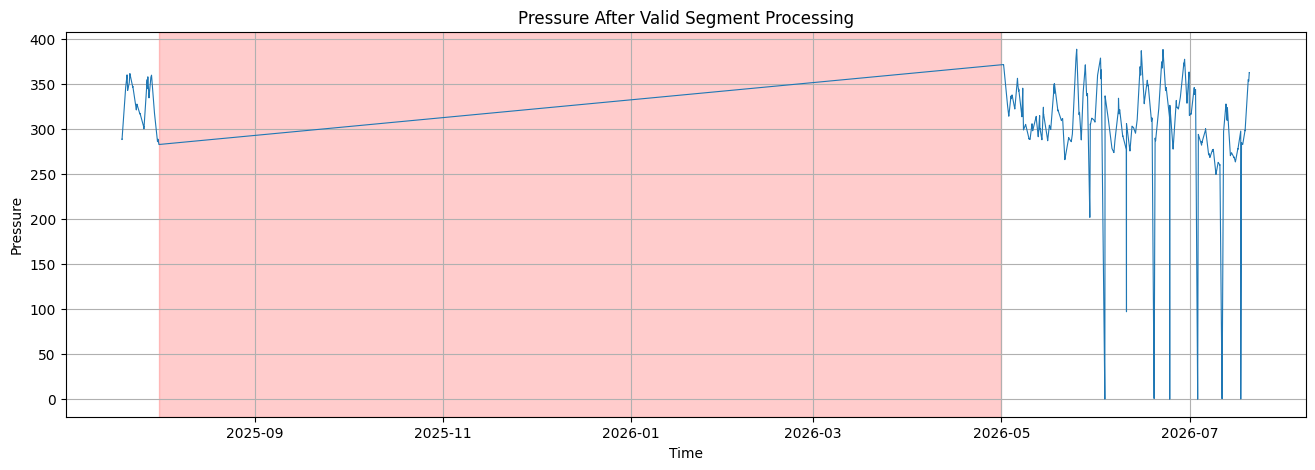

In [145]:
plt.figure(figsize=(16,5))

plt.plot(df_final.index, df_final['pressure'], linewidth=0.8)

plt.axvspan(
    invalid_start,
    invalid_end,
    color='red',
    alpha=0.2
)

plt.title('Pressure After Valid Segment Processing')
plt.xlabel('Time')
plt.ylabel('Pressure')
plt.grid(True)
plt.show()

# CONTINU SEGMENT DETECTION

In [146]:
def split_continuous_segments(df, max_gap_minutes=60, min_length=3):
    gap = df.index.to_series().diff()

    # segmen baru jika gap > 60 menit
    new_segment = gap > pd.Timedelta(minutes=max_gap_minutes)

    segment_id = new_segment.cumsum()

    segments = []

    for _, seg in df.groupby(segment_id):
        if len(seg) >= min_length:
            segments.append(seg)

    return segments

segments = split_continuous_segments(
    df_final,
    max_gap_minutes=60,
    min_length=3
)

print('Jumlah segmen kontinu:', len(segments))

for i, seg in enumerate(segments):
    print(f'Segmen {i+1}: {len(seg)} data')

Jumlah segmen kontinu: 159
Segmen 1: 35 data
Segmen 2: 36 data
Segmen 3: 31 data
Segmen 4: 31 data
Segmen 5: 32 data
Segmen 6: 31 data
Segmen 7: 76 data
Segmen 8: 63 data
Segmen 9: 31 data
Segmen 10: 72 data
Segmen 11: 35 data
Segmen 12: 31 data
Segmen 13: 61 data
Segmen 14: 31 data
Segmen 15: 31 data
Segmen 16: 32 data
Segmen 17: 31 data
Segmen 18: 38 data
Segmen 19: 31 data
Segmen 20: 32 data
Segmen 21: 31 data
Segmen 22: 37 data
Segmen 23: 38 data
Segmen 24: 31 data
Segmen 25: 63 data
Segmen 26: 31 data
Segmen 27: 73 data
Segmen 28: 31 data
Segmen 29: 31 data
Segmen 30: 62 data
Segmen 31: 32 data
Segmen 32: 31 data
Segmen 33: 31 data
Segmen 34: 63 data
Segmen 35: 32 data
Segmen 36: 31 data
Segmen 37: 31 data
Segmen 38: 32 data
Segmen 39: 63 data
Segmen 40: 31 data
Segmen 41: 31 data
Segmen 42: 32 data
Segmen 43: 31 data
Segmen 44: 64 data
Segmen 45: 42 data
Segmen 46: 31 data
Segmen 47: 31 data
Segmen 48: 41 data
Segmen 49: 78 data
Segmen 50: 40 data
Segmen 51: 63 data
Segmen 52: 31

In [147]:
continuous_df = pd.concat(segments)

continuous_df = continuous_df.sort_index()

print('Shape continuous_df:', continuous_df.shape)
print('Range:', continuous_df.index.min(), '->', continuous_df.index.max())

Shape continuous_df: (6097, 1)
Range: 2025-07-20 00:00:00 -> 2026-07-20 08:34:00


In [148]:
print('Jumlah segmen:', len(segments))

# lihat panjang segmen sebelum difilter
gap = df_final.index.to_series().diff()
new_segment = gap > pd.Timedelta(minutes=5)
segment_id = new_segment.cumsum()

for i, (_, seg) in enumerate(df_final.groupby(segment_id)):
    print(f'Segmen {i+1}: {len(seg)} data')

Jumlah segmen: 159
Segmen 1: 35 data
Segmen 2: 36 data
Segmen 3: 31 data
Segmen 4: 31 data
Segmen 5: 32 data
Segmen 6: 31 data
Segmen 7: 76 data
Segmen 8: 63 data
Segmen 9: 31 data
Segmen 10: 31 data
Segmen 11: 41 data
Segmen 12: 35 data
Segmen 13: 31 data
Segmen 14: 61 data
Segmen 15: 31 data
Segmen 16: 31 data
Segmen 17: 32 data
Segmen 18: 31 data
Segmen 19: 38 data
Segmen 20: 31 data
Segmen 21: 32 data
Segmen 22: 1 data
Segmen 23: 31 data
Segmen 24: 37 data
Segmen 25: 38 data
Segmen 26: 31 data
Segmen 27: 31 data
Segmen 28: 32 data
Segmen 29: 31 data
Segmen 30: 42 data
Segmen 31: 31 data
Segmen 32: 31 data
Segmen 33: 31 data
Segmen 34: 31 data
Segmen 35: 31 data
Segmen 36: 32 data
Segmen 37: 31 data
Segmen 38: 31 data
Segmen 39: 32 data
Segmen 40: 31 data
Segmen 41: 32 data
Segmen 42: 31 data
Segmen 43: 31 data
Segmen 44: 32 data
Segmen 45: 31 data
Segmen 46: 32 data
Segmen 47: 31 data
Segmen 48: 31 data
Segmen 49: 32 data
Segmen 50: 31 data
Segmen 51: 31 data
Segmen 52: 33 data
Seg

# MERGE & TRAINING

In [149]:
all_values = []
segment_lengths = []

for seg in segments:
    values = seg[['pressure']].values
    all_values.append(values)
    segment_lengths.append(len(values))

data = np.concatenate(all_values, axis=0)

print('Shape data gabungan:', data.shape)
print('Jumlah segmen:', len(segment_lengths))
print('Panjang tiap segmen:', segment_lengths[:10])

Shape data gabungan: (6097, 1)
Jumlah segmen: 159
Panjang tiap segmen: [35, 36, 31, 31, 32, 31, 76, 63, 31, 72]


In [150]:
TRAIN_END = pd.Timestamp('2026-06-30 23:59:59')
TEST_START = pd.Timestamp('2026-07-01 00:00:00')
TEST_END   = pd.Timestamp('2026-07-07 23:59:59')

# training = semua data sampai 30 Juni
train_df = continuous_df[
    continuous_df.index <= TRAIN_END
].copy()

# test = 1-7 Juli
test_df = continuous_df[
    (continuous_df.index >= TEST_START) &
    (continuous_df.index <= TEST_END)
].copy()

print('Train shape:', train_df.shape)
print('Test shape :', test_df.shape)

print('\nTrain range:')
print(train_df.index.min(), '->', train_df.index.max())

print('\nTest range:')
print(test_df.index.min(), '->', test_df.index.max())

Train shape: (4774, 1)
Test shape : (437, 1)

Train range:
2025-07-20 00:00:00 -> 2026-06-30 22:56:00

Test range:
2026-07-01 11:59:00 -> 2026-07-07 14:39:00


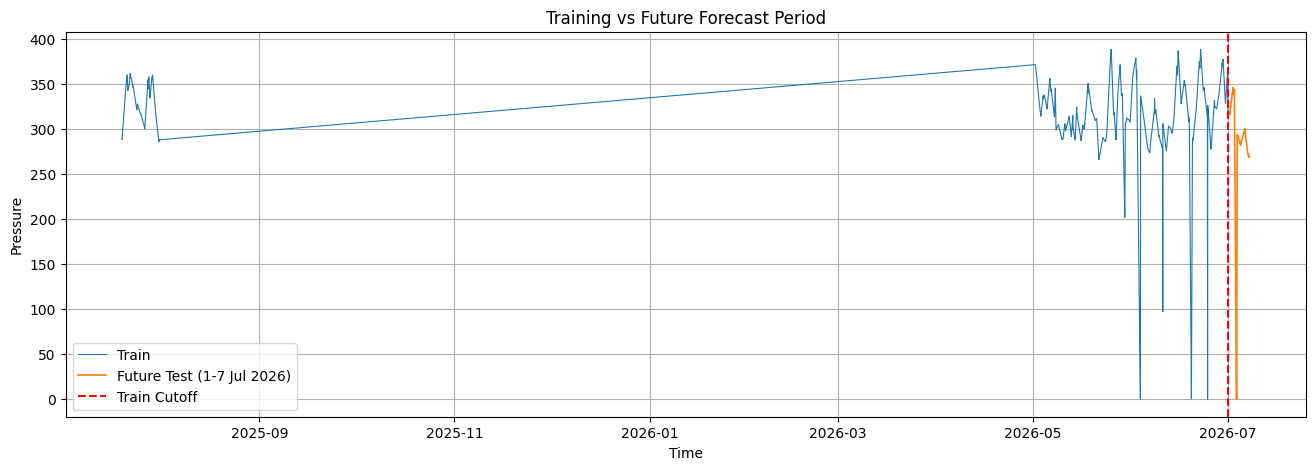

In [151]:
plt.figure(figsize=(16,5))

plt.plot(train_df.index, train_df['pressure'],
         label='Train', linewidth=0.8)

plt.plot(test_df.index, test_df['pressure'],
         label='Future Test (1-7 Jul 2026)', linewidth=1.2)

plt.axvline(TRAIN_END, color='red', linestyle='--', label='Train Cutoff')

plt.title('Training vs Future Forecast Period')
plt.xlabel('Time')
plt.ylabel('Pressure')
plt.legend()
plt.grid(True)
plt.show()

In [152]:
scaler = StandardScaler()

# fit hanya pada train
train_scaled = scaler.fit_transform(train_df[['pressure']])

# test hanya transform
test_scaled = scaler.transform(test_df[['pressure']])

print('Train scaled:', train_scaled.shape)
print('Test scaled :', test_scaled.shape)

Train scaled: (4774, 1)
Test scaled : (437, 1)


In [153]:
print('Mean train:', train_scaled.mean())
print('Std train :', train_scaled.std())

Mean train: 3.2148561148760296e-16
Std train : 1.0


# SAVE OUTPUT & SUMMARY

In [154]:
np.save(PROCESSED_DIR / 'train.npy', train_scaled)
np.save(PROCESSED_DIR / 'test.npy', test_scaled)

joblib.dump(scaler, ARTIFACT_DIR / 'scaler.pkl')

print('Dataset training dan future test berhasil disimpan')

Dataset training dan future test berhasil disimpan
